# Ejemplo de uso

In [1]:
from minisom import MiniSom
import pandas as pd
import numpy as np
columns=['area', 'perimeter', 'compactness', 'length_kernel', 'width_kernel',
                   'asymmetry_coefficient', 'length_kernel_groove', 'target']
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt', 
                    names=columns, 
                   sep='\t+', engine='python')
target = data['target'].values
label_names = {1:'Kama', 2:'Rosa', 3:'Canadian'}
data = data[data.columns[:-1]]
# data normalization
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
data = data.values

In [2]:
# Initialization and training
n_neurons = 9
m_neurons = 9
som = MiniSom(n_neurons, m_neurons, data.shape[1], sigma=1.5, learning_rate=.5, 
              neighborhood_function='gaussian', random_seed=0, topology='rectangular')

som.pca_weights_init(data)
som.train(data, 1000, verbose=True)  # random training

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.506671895909233


C:\Users\abril\anaconda3\lib\site-packages\minisom.py:388: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [3]:
som.topographic_error(data[:100])

0.08

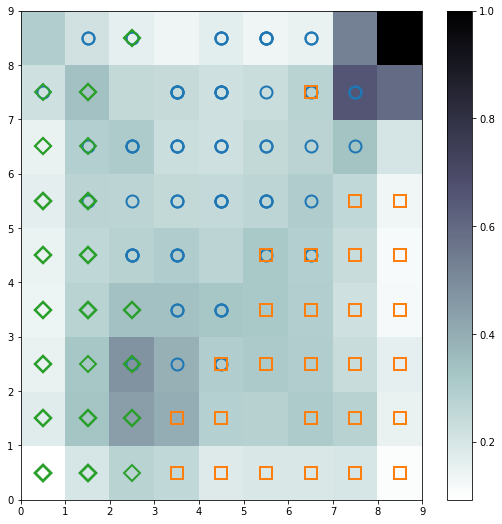

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(9, 9))

plt.pcolor(som.distance_map().T, cmap='bone_r')  # plotting the distance map as background
plt.colorbar()

# Plotting the response for each pattern in the iris dataset
# different colors and markers for each label
markers = ['o', 's', 'D']
colors = ['C0', 'C1', 'C2']
for cnt, xx in enumerate(data):
    w = som.winner(xx)  # getting the winner
    # palce a marker on the winning position for the sample xx
    plt.plot(w[0]+.5, w[1]+.5, markers[target[cnt]-1], markerfacecolor='None',
             markeredgecolor=colors[target[cnt]-1], markersize=12, markeredgewidth=2)

plt.show()

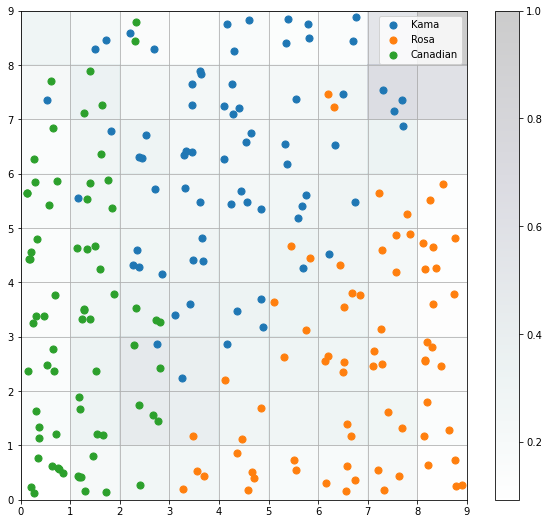

In [5]:
w_x, w_y = zip(*[som.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

plt.figure(figsize=(10, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=.2)
plt.colorbar()

for c in np.unique(target):
    idx_target = target==c
    plt.scatter(w_x[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8,
                w_y[idx_target]+.5+(np.random.rand(np.sum(idx_target))-.5)*.8, 
                s=50, c=colors[c-1], label=label_names[c])
plt.legend(loc='upper right')
plt.grid()
plt.show()

Nota: Usar pcolor sobre esta matriz genera un mapa de calor, donde los colores representan la cercanía entre neuronas: valores claros indican mayores distancias (bordes entre grupos), y valores oscuros, menores distancias (agrupamientos).

# Verificación de que el espacio de muestras para entrenar a los SOMs tiene una distribución gaussiana:

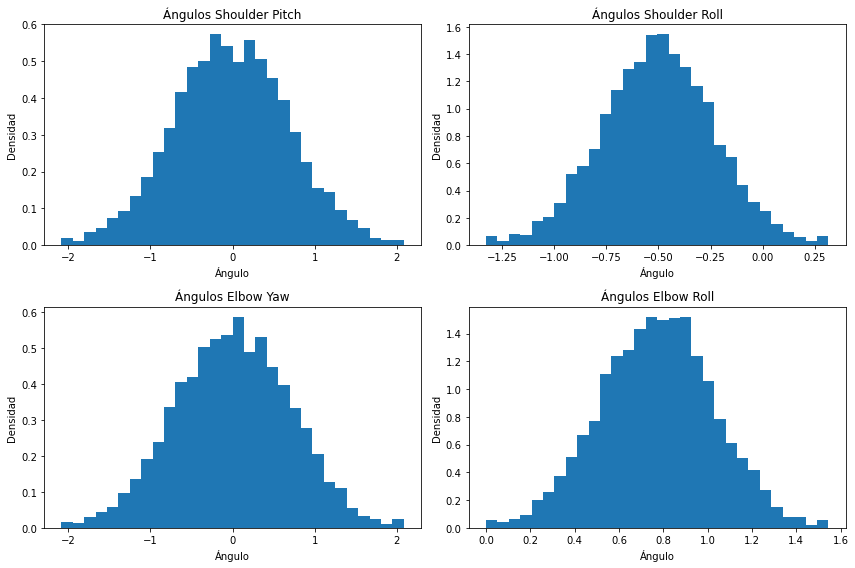

Shapiro-Wilk Test Results:
Shoulder Pitch: ShapiroResult(statistic=0.9993285536766052, pvalue=0.05816951021552086)
Shoulder Roll: ShapiroResult(statistic=0.9992640018463135, pvalue=0.035058148205280304)
Elbow Yaw: ShapiroResult(statistic=0.9992372393608093, pvalue=0.028396429494023323)
Elbow Roll: ShapiroResult(statistic=0.9993337392807007, pvalue=0.06057381257414818)


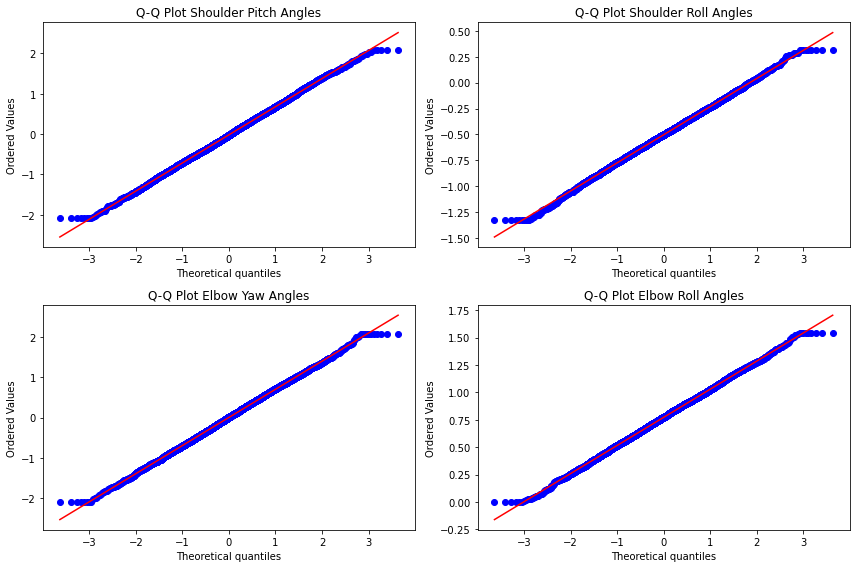

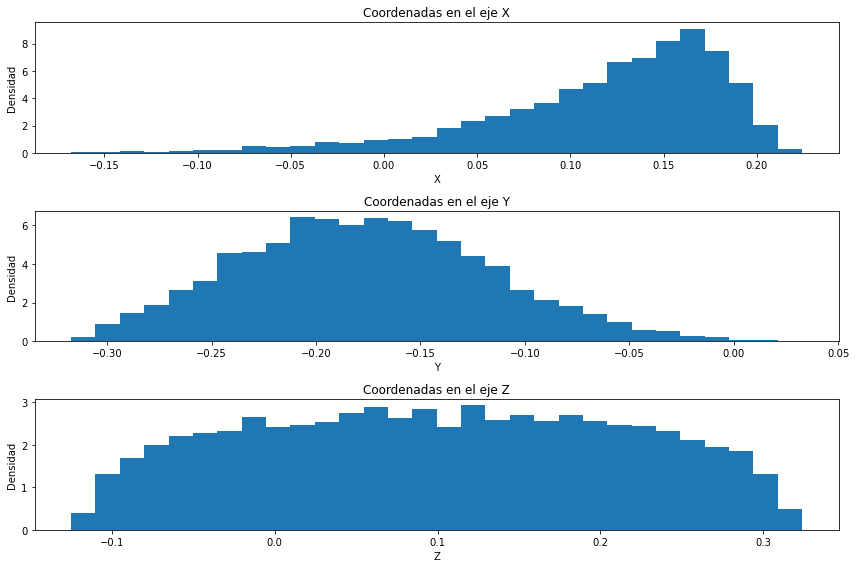

Shapiro-Wilk Test Results for GPS Data:
GPS X: ShapiroResult(statistic=0.9030894041061401, pvalue=0.0)
GPS Y: ShapiroResult(statistic=0.9943127036094666, pvalue=3.5809639216573264e-13)
GPS Z: ShapiroResult(statistic=0.9696340560913086, pvalue=2.8734265864183833e-31)


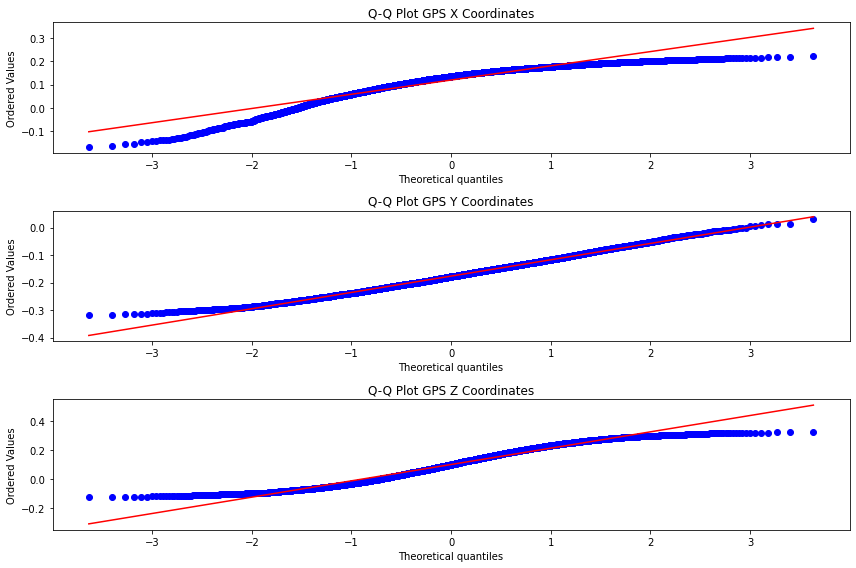

In [1]:
import random
import csv
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Initialize lists to store the generated angles and GPS data
shoulder_pitch_angles = []
shoulder_roll_angles = []
elbow_yaw_angles = []
elbow_roll_angles = []

gps_x = []
gps_y = []
gps_z = []

motor_data = []
gps_data = []


    
with open("my_project\controllers\my_controller\motor_angles.csv", "r", newline='') as motor_csvfile:
    motor_reader = csv.reader(motor_csvfile)
   
    for row in motor_reader:
        motor_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
    
# Leer los datos del GPS del CSV
with open("my_project\controllers\my_controller\gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice



# Assign the motor data to the respective angle lists
for data in motor_data:
    shoulder_pitch_angles.append(data[0])
    shoulder_roll_angles.append(data[1])
    elbow_yaw_angles.append(data[2])
    elbow_roll_angles.append(data[3])
    
# Assign the motor data to the respective angle lists
for data in gps_data:
    gps_x.append(data[0])
    gps_y.append(data[1])
    gps_z.append(data[2])

#Print the lists to verify the data
#print("Shoulder Pitch Angles:", shoulder_pitch_angles)
#print("GPS_x:", gps_x)

# Plot histograms-angles
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(shoulder_pitch_angles, bins=30, density=True)
plt.title("Ángulos Shoulder Pitch")
plt.xlabel("Ángulo")
plt.ylabel("Densidad")

plt.subplot(2, 2, 2)
plt.hist(shoulder_roll_angles, bins=30, density=True)
plt.title("Ángulos Shoulder Roll")
plt.xlabel("Ángulo")
plt.ylabel("Densidad")

plt.subplot(2, 2, 3)
plt.hist(elbow_yaw_angles, bins=30, density=True)
plt.title("Ángulos Elbow Yaw")
plt.xlabel("Ángulo")
plt.ylabel("Densidad")

plt.subplot(2, 2, 4)
plt.hist(elbow_roll_angles, bins=30, density=True)
plt.title("Ángulos Elbow Roll")
plt.xlabel("Ángulo")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

#Perform Shapiro-Wilk test
print("Shapiro-Wilk Test Results:")
print(f"Shoulder Pitch: {stats.shapiro(shoulder_pitch_angles)}")
print(f"Shoulder Roll: {stats.shapiro(shoulder_roll_angles)}")
print(f"Elbow Yaw: {stats.shapiro(elbow_yaw_angles)}")
print(f"Elbow Roll: {stats.shapiro(elbow_roll_angles)}")

#Plot Q-Q plots
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
stats.probplot(shoulder_pitch_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Shoulder Pitch Angles")

plt.subplot(2, 2, 2)
stats.probplot(shoulder_roll_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Shoulder Roll Angles")

plt.subplot(2, 2, 3)
stats.probplot(elbow_yaw_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Elbow Yaw Angles")

plt.subplot(2, 2, 4)
stats.probplot(elbow_roll_angles, dist="norm", plot=plt)
plt.title("Q-Q Plot Elbow Roll Angles")

plt.tight_layout()
plt.show()

# Plot histograms-gps
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(gps_x, bins=30, density=True)
plt.title("Coordenadas en el eje X")
plt.xlabel("X")
plt.ylabel("Densidad")

plt.subplot(3, 1, 2)
plt.hist(gps_y, bins=30, density=True)
plt.title("Coordenadas en el eje Y")
plt.xlabel("Y")
plt.ylabel("Densidad")

plt.subplot(3, 1, 3)
plt.hist(gps_z, bins=30, density=True)
plt.title("Coordenadas en el eje Z")
plt.xlabel("Z")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()


# Perform Shapiro-Wilk test for GPS data
print("Shapiro-Wilk Test Results for GPS Data:")
print(f"GPS X: {stats.shapiro(gps_x)}")
print(f"GPS Y: {stats.shapiro(gps_y)}")
print(f"GPS Z: {stats.shapiro(gps_z)}")

# Plot Q-Q plots for GPS data
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
stats.probplot(gps_x, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS X Coordinates")

plt.subplot(3, 1, 2)
stats.probplot(gps_y, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS Y Coordinates")

plt.subplot(3, 1, 3)
stats.probplot(gps_z, dist="norm", plot=plt)
plt.title("Q-Q Plot GPS Z Coordinates")

plt.tight_layout()
plt.show()

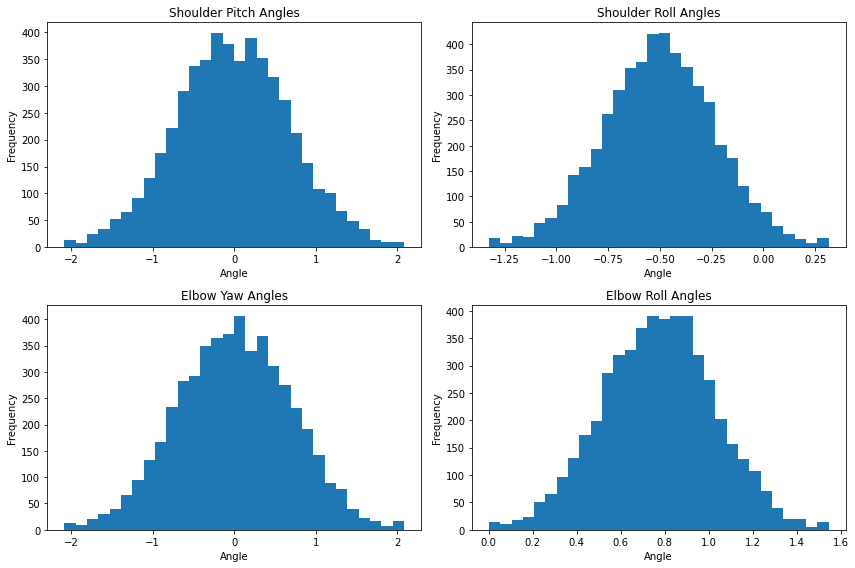

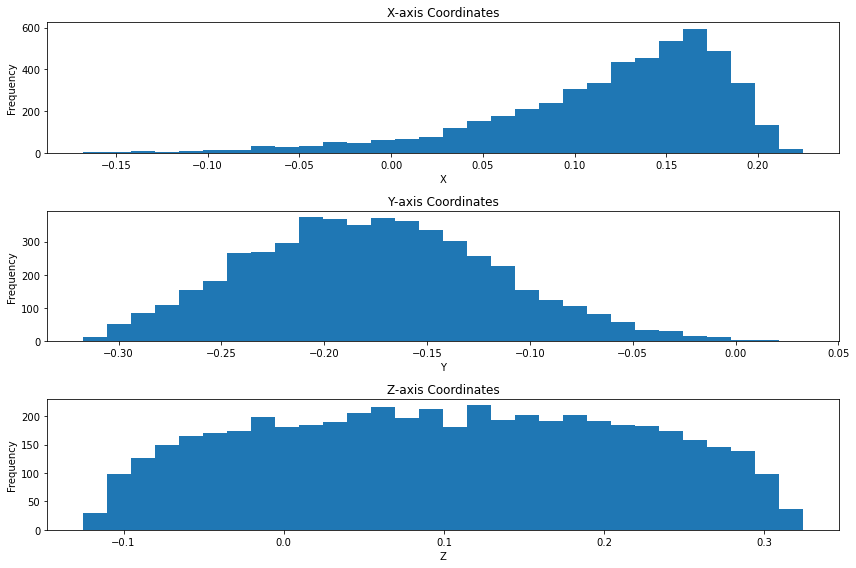

In [2]:
# Plot histograms-angles
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(shoulder_pitch_angles, bins=30)  
plt.title("Shoulder Pitch Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 

plt.subplot(2, 2, 2)
plt.hist(shoulder_roll_angles, bins=30) 
plt.title("Shoulder Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 

plt.subplot(2, 2, 3)
plt.hist(elbow_yaw_angles, bins=30) 
plt.title("Elbow Yaw Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 

plt.subplot(2, 2, 4)
plt.hist(elbow_roll_angles, bins=30)  
plt.title("Elbow Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency")  

plt.tight_layout()
plt.savefig('Angles_distribution.png', format='png', dpi=300)
plt.show()

# Plot histograms-gps
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(gps_x, bins=30)  
plt.title("X-axis Coordinates")
plt.xlabel("X")
plt.ylabel("Frequency")  

plt.subplot(3, 1, 2)
plt.hist(gps_y, bins=30) 
plt.title("Y-axis Coordinates")
plt.xlabel("Y")
plt.ylabel("Frequency") 

plt.subplot(3, 1, 3)
plt.hist(gps_z, bins=30) 
plt.title("Z-axis Coordinates")
plt.xlabel("Z")
plt.ylabel("Frequency")  

plt.tight_layout()
plt.savefig('GPS_distribution.png', format='png', dpi=300)
plt.show()


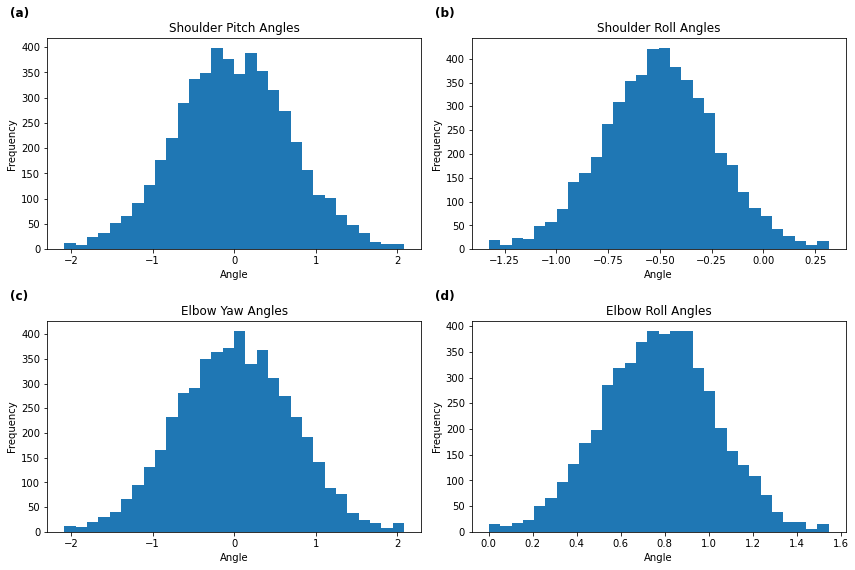

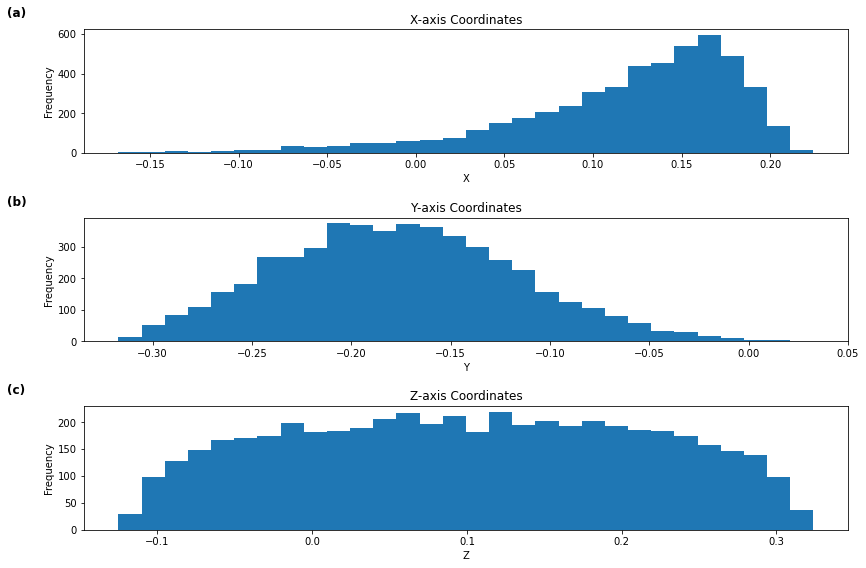

In [3]:
# Plot histograms-angles
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(shoulder_pitch_angles, bins=30)  
plt.title("Shoulder Pitch Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 
plt.text(-0.1, 1.1, "(a)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.subplot(2, 2, 2)
plt.hist(shoulder_roll_angles, bins=30) 
plt.title("Shoulder Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 
plt.text(-0.1, 1.1, "(b)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.subplot(2, 2, 3)
plt.hist(elbow_yaw_angles, bins=30) 
plt.title("Elbow Yaw Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency") 
plt.text(-0.1, 1.1, "(c)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.subplot(2, 2, 4)
plt.hist(elbow_roll_angles, bins=30)  
plt.title("Elbow Roll Angles")
plt.xlabel("Angle")
plt.ylabel("Frequency")  
plt.text(-0.1, 1.1, "(d)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig('Angles_distribution.png', format='png', dpi=300)
plt.show()

# Plot histograms-gps
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(gps_x, bins=30)  
plt.title("X-axis Coordinates")
plt.xlabel("X")
plt.ylabel("Frequency")  
plt.text(-0.1, 1.1, "(a)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.subplot(3, 1, 2)
plt.hist(gps_y, bins=30) 
plt.title("Y-axis Coordinates")
plt.xlabel("Y")
plt.ylabel("Frequency") 
plt.text(-0.1, 1.1, "(b)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.subplot(3, 1, 3)
plt.hist(gps_z, bins=30) 
plt.title("Z-axis Coordinates")
plt.xlabel("Z")
plt.ylabel("Frequency")  
plt.text(-0.1, 1.1, "(c)", transform=plt.gca().transAxes, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig('GPS_distribution.png', format='png', dpi=300)
plt.show()


# Distribution of SOM Visual

In [34]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

sampleSize=5000

#normalize a data set
def min_max_normalize(x):
    min_val = np.min(x, axis=0)
    max_val = np.max(x, axis=0)
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

# Load data
columns = ['Key','X', 'Y', 'Z']
data = pd.read_csv('my_project\controllers\my_controller\gps_hand.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = min_max_normalize(data)
data = data.values

with open('my_project\controllers\my_controller\somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

somVisual.topographic_error(data[:sampleSize])

0.1324

<IPython.core.display.Javascript object>


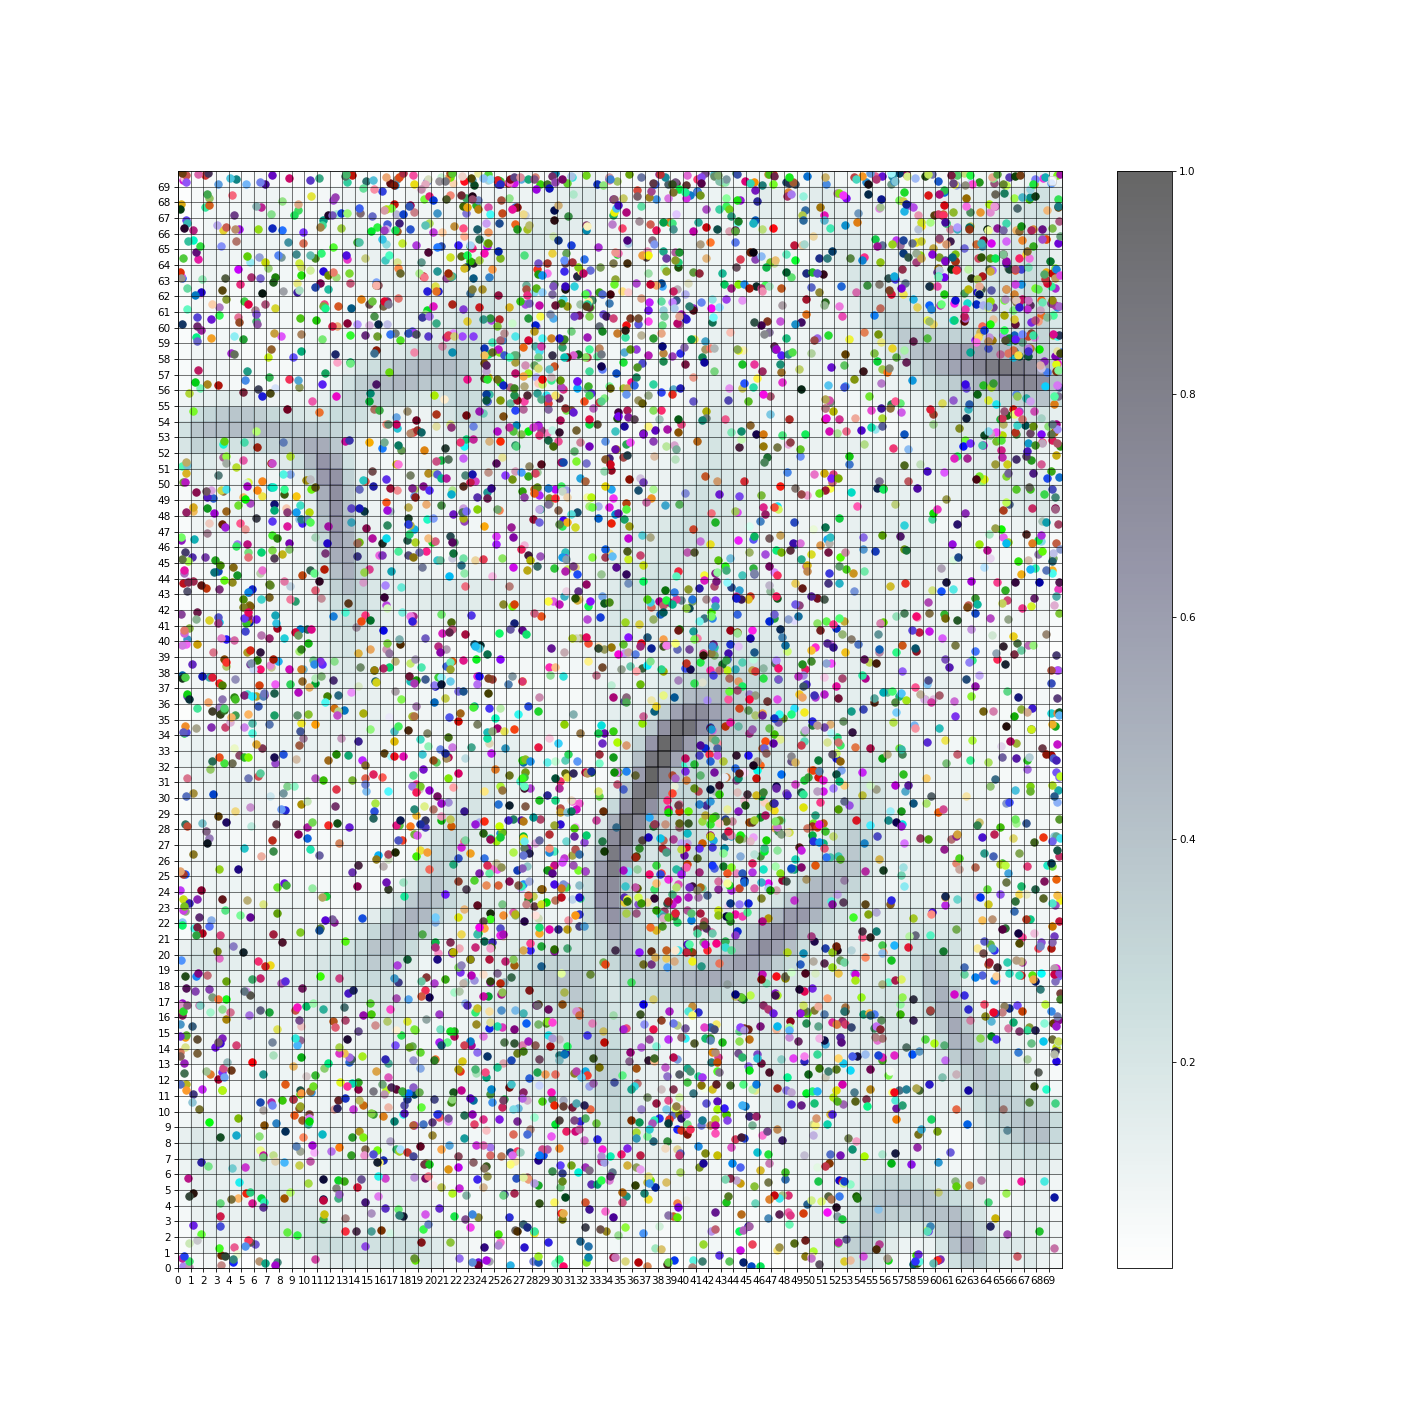

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [36]:
# plot som
w_x, w_y = zip(*[somVisual.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(sampleSize)]

plt.figure(figsize=(19, 19))

plt.pcolor(somVisual.distance_map().T, cmap='bone_r', alpha=0.6)
plt.colorbar()

plt.xticks(np.arange(0, 70, 1))
plt.yticks(np.arange(0, 70, 1))
plt.xlim(0, 70)
plt.ylim(0, 70)

# Cuadrícula para cada neurona
plt.grid(color='black', linestyle='-', linewidth=0.5)  # Color y grosor de la cuadrícula

for c in np.unique(target):
    idx_target = target == c
    plt.scatter(
        w_x[idx_target] + 0.5 + (np.random.rand(np.sum(idx_target)) - 0.5) * 0.8,
        w_y[idx_target] + 0.5 + (np.random.rand(np.sum(idx_target)) - 0.5) * 0.8,
        s=50,
        c=colors[c - 1]
    )

plt.legend(loc='upper right')
plt.savefig('somVisual_plot.png', format='png', dpi=300)
plt.show()

# Distribution of SOM Motor

In [37]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

sampleSize=5000

#normalize a data set
def min_max_normalize(x):
    min_val = np.min(x, axis=0)
    max_val = np.max(x, axis=0)
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

# Load data
columns = ['Key','RShoulderPitch', 'RShoulderRoll', 'RElbowYaw', 'RElbowRoll']
data = pd.read_csv('my_project\controllers\my_controller\motor_angles.csv', names=columns, sep=',', engine='python')


target = data['Key'].values

#print(target)
# Remove first column 
data = data[data.columns[1:]]
#print(data)
# Data normalization
data = min_max_normalize(data)
data = data.values

with open('my_project\controllers\my_controller\somAngles.p', 'rb') as infile:
    somAngles = pickle.load(infile)

somAngles.topographic_error(data[:sampleSize])

0.0534

<IPython.core.display.Javascript object>


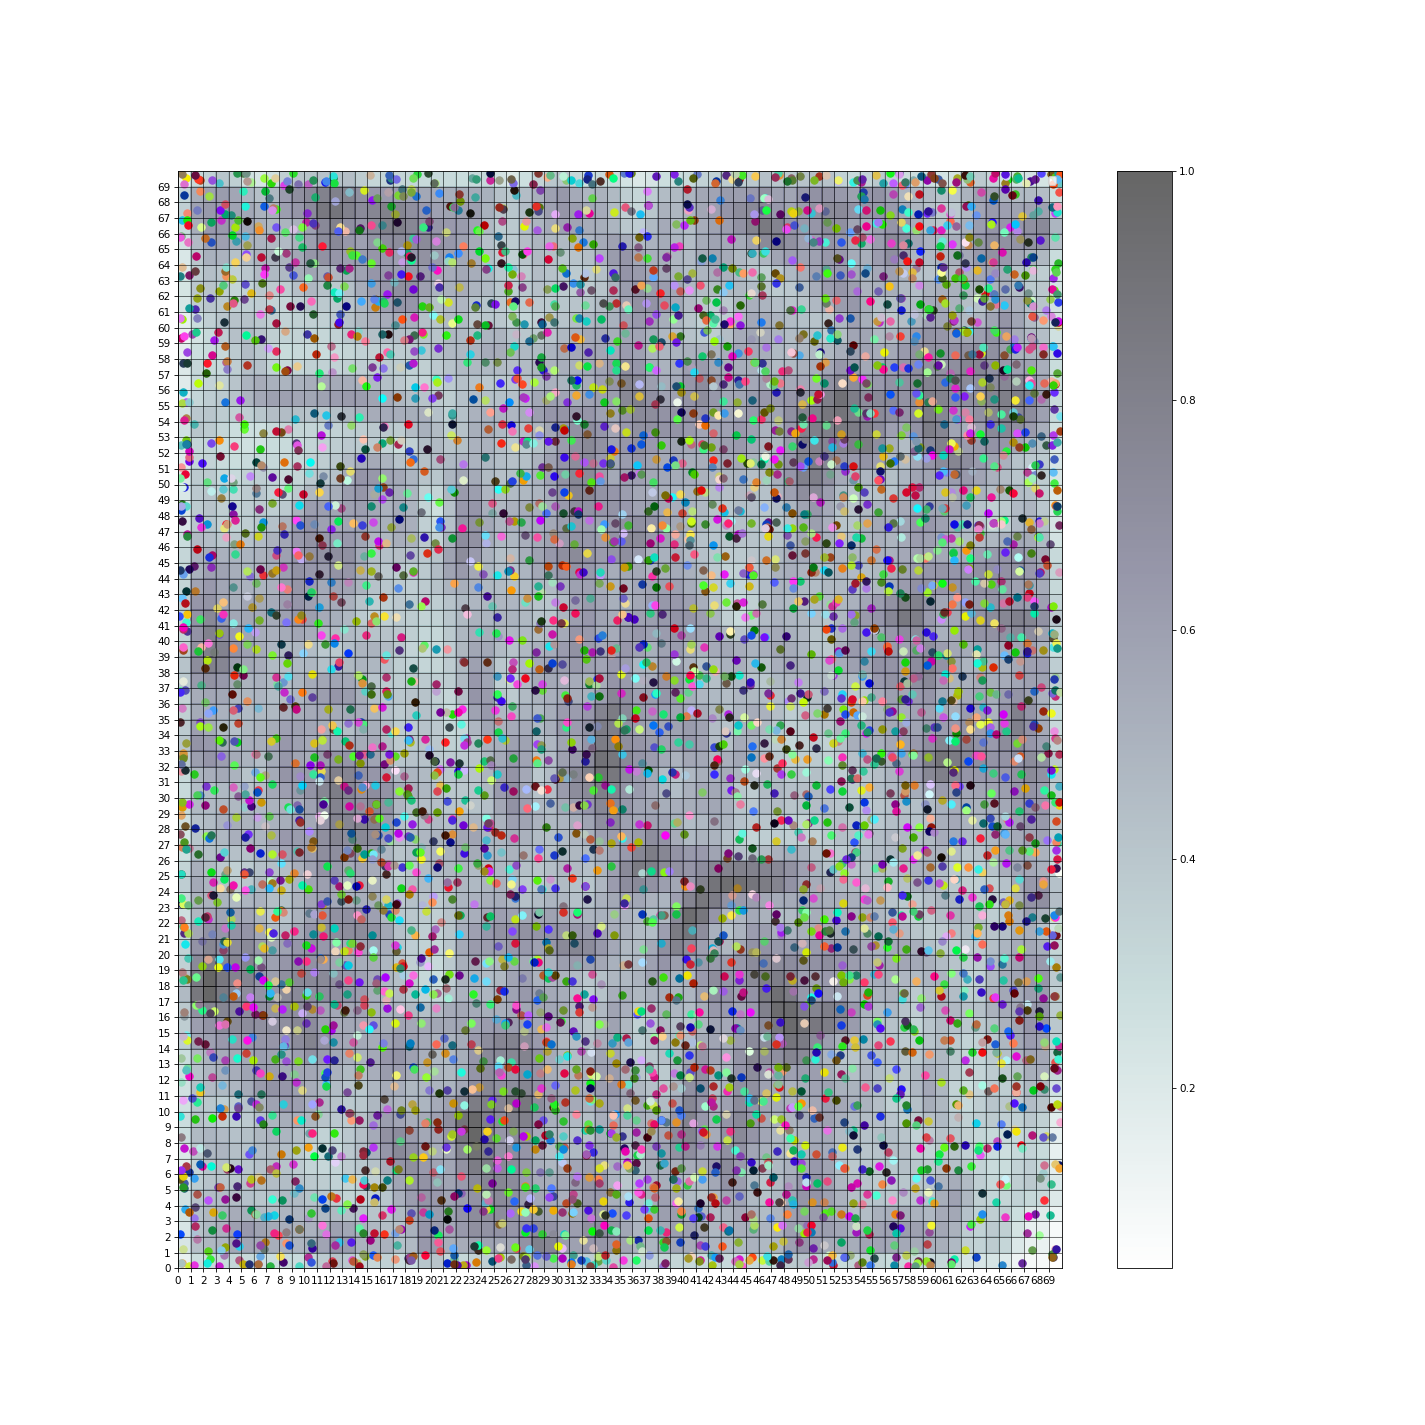

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [38]:
# plot som
w_x, w_y = zip(*[somAngles.winner(d) for d in data])
w_x = np.array(w_x)
w_y = np.array(w_y)

colors = ['#' + ''.join(random.choices('0123456789ABCDEF', k=6)) for _ in range(sampleSize)]

plt.figure(figsize=(19, 19))

plt.pcolor(somAngles.distance_map().T, cmap='bone_r', alpha=0.6)
plt.colorbar()

plt.xticks(np.arange(0, 70, 1))
plt.yticks(np.arange(0, 70, 1))
plt.xlim(0, 70)
plt.ylim(0, 70)

# Cuadrícula para cada neurona
plt.grid(color='black', linestyle='-', linewidth=0.5)  # Color y grosor de la cuadrícula

for c in np.unique(target):
    idx_target = target == c
    plt.scatter(
        w_x[idx_target] + 0.5 + (np.random.rand(np.sum(idx_target)) - 0.5) * 0.8,
        w_y[idx_target] + 0.5 + (np.random.rand(np.sum(idx_target)) - 0.5) * 0.8,
        s=50,
        c=colors[c - 1]
    )

plt.legend(loc='upper right')
plt.savefig('somAngles_plot.png', format='png', dpi=300)
plt.show()

# Visual SOM distribution on 3D space

<IPython.core.display.Javascript object>


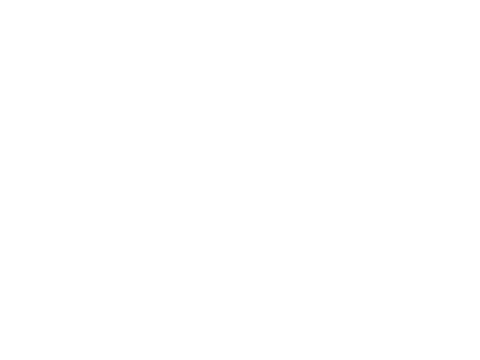

In [4]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle
import csv

%matplotlib notebook


def denormalize_vector(normalized_vector, data):
    """
    Takes a normalized vector and a dataset to return a denormalized version of the vector. 
    Args:
        -normalized_vector: A list or array representing a vector with values normalized between 0 and 1.
        -data: A dataset used to retrieve the minimum and maximum values for each feature, which is necessary for the denormalization process.

    Returns:
        A denormalized vector, where each element corresponds to its original scale based on the dataset's feature ranges.
    """    
    # Calculate min and max for each feature in the dataset
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Denormalize the vector
    denormalized_vector = []
    for i in range(len(normalized_vector)):
        denormalized_value = normalized_vector[i] * (max_values[i] - min_values[i]) + min_values[i]
        denormalized_vector.append(denormalized_value)
        
    denormalized_vector=np.round(denormalized_vector,4)
    return denormalized_vector

data = []

# Leer los datos del GPS del CSV
with open("my_project/controllers/my_controller/gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
            
with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

weights_matrix = somVisual.get_weights()
#print(weights_matrix.shape)

denormalized_weights = []

for row in weights_matrix:
    denormalized_row = []
    for vector in row:
        denormalized_vector = denormalize_vector(vector, data)
        
        denormalized_row.append(denormalized_vector)
    denormalized_weights.append(denormalized_row)

denormalized_weights = np.array(denormalized_weights)
#print(denormalized_weights)
x = []
y = []
z = []
labels = []

for i in range(denormalized_weights.shape[0]):
    for j in range(denormalized_weights.shape[1]):
        vector = denormalized_weights[i, j]
        x.append(vector[0])
        y.append(vector[1])
        z.append(vector[2])
        labels.append(f"({i}, {j})")

colors = np.random.rand(len(x), 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=colors, marker='o', s=10)

for xi, yi, zi, label in zip(x, y, z, labels):
    ax.text(xi, yi, zi, label, fontsize=8)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

ax.set_xlim([-5, 5])
ax.set_ylim([-2, 2])
ax.set_zlim([-10, 10])
plt.show()

(70, 70, 4)


<IPython.core.display.Javascript object>


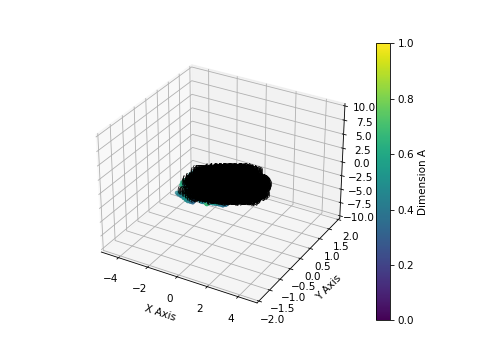

In [5]:
from minisom import MiniSom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle
import csv

%matplotlib notebook


def denormalize_vector(normalized_vector, data):
    """
    Takes a normalized vector and a dataset to return a denormalized version of the vector. 
    Args:
        -normalized_vector: A list or array representing a vector with values normalized between 0 and 1.
        -data: A dataset used to retrieve the minimum and maximum values for each feature, which is necessary for the denormalization process.

    Returns:
        A denormalized vector, where each element corresponds to its original scale based on the dataset's feature ranges.
    """    
    # Calculate min and max for each feature in the dataset
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Denormalize the vector
    denormalized_vector = []
    for i in range(len(normalized_vector)):
        denormalized_value = normalized_vector[i] * (max_values[i] - min_values[i]) + min_values[i]
        denormalized_vector.append(denormalized_value)
        
    denormalized_vector=np.round(denormalized_vector,4)
    return denormalized_vector

data = []

# Leer los datos del GPS del CSV
with open("my_project/controllers/my_controller/motor_angles.csv", "r", newline='') as mtr_csvfile:
    motor_reader = csv.reader(mtr_csvfile)
   
    for row in motor_reader:
        data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
            
#print(data)
with open('my_project/controllers/my_controller/somAngles.p', 'rb') as infile:
    somAngles = pickle.load(infile)

weights_matrix = somAngles.get_weights()
print(weights_matrix.shape)

denormalized_weights = []

for row in weights_matrix:
    denormalized_row = []
    for vector in row:
        denormalized_vector = denormalize_vector(vector, data)
        
        denormalized_row.append(denormalized_vector)
    denormalized_weights.append(denormalized_row)

denormalized_weights = np.array(denormalized_weights)
#print(denormalized_weights)
x = []
y = []
z = []
a= []
labels = []

for i in range(denormalized_weights.shape[0]):
    for j in range(denormalized_weights.shape[1]):
        vector = denormalized_weights[i, j]
        x.append(vector[0])
        y.append(vector[1])
        z.append(vector[2])
        a.append(vector[3])
        labels.append(f"({i}, {j})")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') 

# Normalizar la cuarta dimensión para mapearla a colores
a_normalized = (np.array(a) - np.min(a)) / (np.max(a) - np.min(a))

scatter = ax.scatter(x, y, z, c=a_normalized, cmap='viridis', marker='o', s=10)

for xi, yi, zi, label in zip(x, y, z, labels):
    ax.text(xi, yi, zi, label, fontsize=8)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

ax.set_xlim([-5, 5])
ax.set_ylim([-2, 2])
ax.set_zlim([-10, 10])

cbar = fig.colorbar(scatter, ax=ax, label='Dimension A')

plt.show()

In [6]:
import numpy as np
from minisom import MiniSom
import csv
import pickle

def min_max_normalize(x):
    """
    Performs min-max normalization on a dataset or vector.

    Args:
        -x: A dataset to be normalized.

    Returns:
        A normalized version of x, where each value is scaled between 0 and 1.
    """    
    #Get the min value of the dataset
    min_val = np.min(x, axis=0)
    #Get the max value of the dataset
    max_val = np.max(x, axis=0)
    #min_max normalization
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

visual_data = []

# Leer los datos del GPS del CSV
with open("my_project/controllers/my_controller/gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        visual_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
            
with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

    
normalized_visual_data= min_max_normalize(visual_data)

# Calcular el error de cuantización
quantization_error = np.mean([np.linalg.norm(vector - somVisual.get_weights()[somVisual.winner(vector)]) for vector in normalized_visual_data])

print(f"Error de cuantización: {quantization_error}")

variances = np.var(normalized_data, axis=0)
print("Varianzas por característica:", variances)


Error de cuantización: 0.01905048191885897


NameError: name 'normalized_data' is not defined

In [ ]:
import numpy as np
from minisom import MiniSom


def min_max_normalize(x):
    """
    Performs min-max normalization on a dataset or vector.

    Args:
        -x: A dataset to be normalized.

    Returns:
        A normalized version of x, where each value is scaled between 0 and 1.
    """    
    #Get the min value of the dataset
    min_val = np.min(x, axis=0)
    #Get the max value of the dataset
    max_val = np.max(x, axis=0)
    #min_max normalization
    normalized_x = (x - min_val) / (max_val - min_val)
    return normalized_x

data = []

# Leer los datos del GPS del CSV
with open("my_project/controllers/my_controller/motor_angles.csv", "r", newline='') as mtr_csvfile:
    motor_reader = csv.reader(mtr_csvfile)
   
    for row in motor_reader:
        data.append([float(value) for value in row[1:]])  
            
with open('my_project/controllers/my_controller/somAngles.p', 'rb') as infile:
    somAngles = pickle.load(infile)

    
normalized_data= min_max_normalize(data)

# Calcular el error de cuantización
quantization_error = np.mean([np.linalg.norm(vector - somAngles.get_weights()[somAngles.winner(vector)]) for vector in normalized_data])

print(f"Error de cuantización: {quantization_error}")

motor_data_normalized=min_max_normalize(motor_data)
variances = np.var(motor_data_normalized, axis=0)
print("Varianzas por característica:", variances)


In [ ]:
def totalerrorindataSOM(som, train_data):
    total_error = 0
    train_data_normalized = min_max_normalize(train_data)
    for data, original in zip(train_data_normalized, train_data):
        
        weights = som.get_weights()
        
        # Encontrar el BMU
        bmu = som.winner(data)  
        bmu_position = weights[bmu[0], bmu[1]]
        
        # Desnormalizar el vector del BMU
        bmu_position_denormalized = denormalize_vector(bmu_position, train_data)
        
        # Calcular la distancia Euclidiana entre la posición original y la del BMU
        distance = np.linalg.norm(original - bmu_position_denormalized)
        total_error += distance

    average_error = total_error / len(train_data)
    return average_error

print(f"Total error after denormalizing BMU Visual: {totalerrorindataSOM(somVisual, visual_data)}")
print(f"Total error after denormalizing BMU Visual: {totalerrorindataSOM(somAngles, data)}")